# Query to reference mapping
In this tutorial, we will demonstrate how CellMapper can be used in the general query-to-reference mapping scenario, where we have two datasets from the same modality (e.g. scRNA-seq). We'll use scVI {cite:p}`lopez2018deep` to get a joint latent space, and we'll use CellMapper in that space to transfer cell type labels, evaluate the quality of label transfer, and compute presence scores. 

This tutorial is inspired by an [scVI tutorial](https://docs.scvi-tools.org/en/stable/tutorials/notebooks/scrna/harmonization.html) on the same dataset, and an [HNOCA-tools tutorial](https://devsystemslab.github.io/HNOCA-tools/vignettes/reference_mapping/) {cite:p}`he2024integrated` showcasing similar techniques. 

## Preliminaries

### Import packages & data

In [1]:
%load_ext autoreload
%autoreload 2

In [56]:
import scanpy as sc
import numpy as np
import pandas as pd
from pathlib import Path
import cellmapper
import matplotlib.pyplot as plt

import torch
import scvi

import anndata as ad

In [3]:
sc.set_figure_params(scanpy=True, frameon=False, fontsize=10)

# some torch and scvi-tools settings
torch.set_float32_matmul_precision("high")
scvi.settings.dl_num_workers = 15  # will depend on your system

MODEL_DIR = Path("models/lung")

### Data loading

Load the lung data {cite:p}`vieira2019cellular` that has been used in the scIB lung integration challenge {cite:p}`luecken2022benchmarking`, following the scVI tutorial on [Atlas-level integration of lung data](https://docs.scvi-tools.org/en/stable/tutorials/notebooks/scrna/harmonization.html). 

In [4]:
adata = sc.read(
    "data/lung_atlas_preprocessed.h5ad",
    backup_url="https://figshare.com/ndownloader/files/52859312",
)
adata

100%|██████████| 628M/628M [00:14<00:00, 45.3MB/s]    


AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg'
    layers: 'counts'

### Prepare the data

Compute a basic umap without batch correction. 

In [5]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

Split the data into query and reference datasets. 

In [6]:
query_batches = ["4", "A2", "B3"]

adata.obs["split"] = pd.Categorical(
    np.where(adata.obs["batch"].isin(query_batches), "query", "reference"), categories=["query", "reference"]
)

Visualize this split, some sample covariates, and cell type labels. 

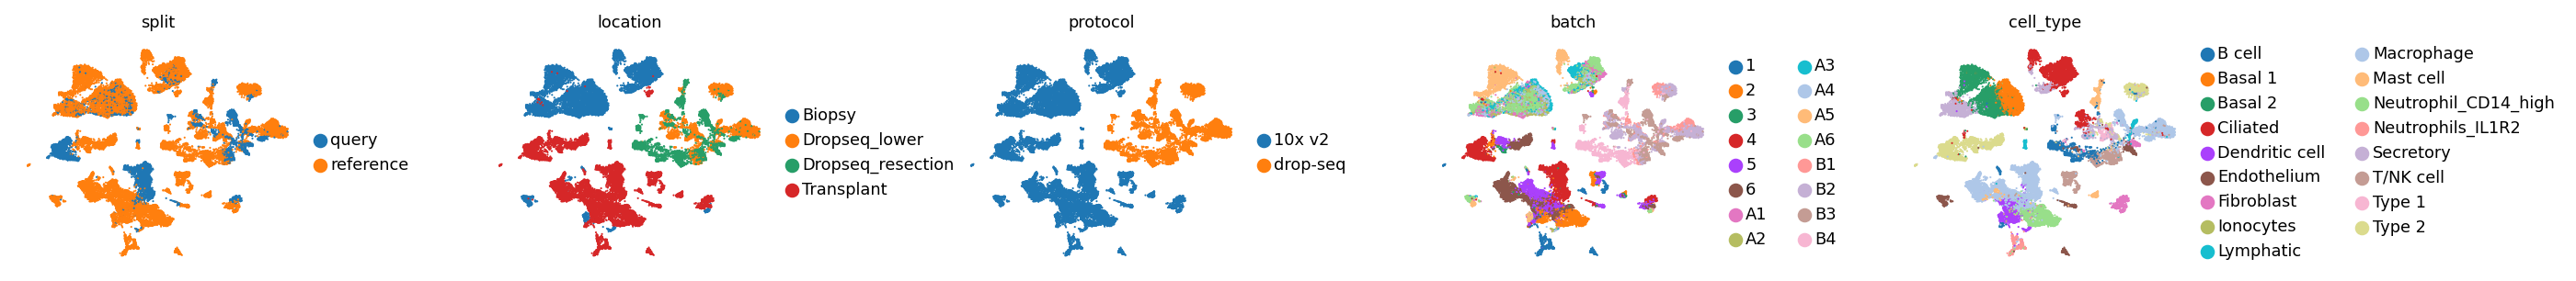

In [50]:
with plt.rc_context({"figure.figsize": (2.5, 2), "legend.fontsize": 8, "axes.titlesize": 8}):
    sc.pl.embedding(
        adata, basis="umap", color=["split", "location", "protocol", "batch", "cell_type"], ncols=5, wspace=0.5
    )

Split the AnnData into two objects. 

In [8]:
ad_query = adata[adata.obs["split"] == "query"].copy()
ad_reference = adata[adata.obs["split"] == "reference"].copy()

Take a look at cell and gene numbers here. 

In [9]:
ad_query.shape, ad_reference.shape

((7128, 2000), (25344, 2000))

## Main analysis

### Train scVI reference model

In [10]:
scvi.model.SCVI.setup_anndata(ad_reference, batch_key="batch", layer="counts")

/cluster/project/treutlein/USERS/mlange/github/scvi-tools/src/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Create and tain the reference model. 

In [19]:
# scvi_ref = scvi.model.SCVI(
#     ad_reference,
#     use_layer_norm="both",
#     use_batch_norm="none",
#     encode_covariates=True,
#     dropout_rate=0.2,
#     gene_likelihood="nb",
#     n_latent=30,
#     n_layers=2,
# )

# scvi_ref.train()

# # write model to file
# scvi_ref.save(MODEL_DIR / "scvi_ref", overwrite=True)

Load a pre-trained model. 

In [11]:
scvi_ref = scvi.model.SCVI.load(MODEL_DIR / "scvi_ref", adata=ad_reference)

INFO     File models/lung/scvi_ref/model.pt already downloaded                                                     


/cluster/project/treutlein/USERS/mlange/miniforge3/envs/rapids_jax/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /cluster/project/treutlein/USERS/mlange/miniforge3/e ...
/cluster/project/treutlein/USERS/mlange/github/scvi-tools/src/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Extract the latent space coordinates

In [12]:
SCVI_LATENT_KEY = "X_scVI"

ad_reference.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()

### Update with the query

In [13]:
scvi.model.SCVI.prepare_query_anndata(ad_query, scvi_ref)

INFO     Found 100.0% reference vars in query data.                                                                


Create and train the query model

In [18]:
# scvi_query = scvi.model.SCVI.load_query_data(ad_query, scvi_ref)

# scvi_query.train(max_epochs=200, plan_kwargs={"weight_decay": 0.0})

# # write model to file
# scvi_query.save(MODEL_DIR / "scvi_query", overwrite=True)

Load a pre-trained model. 

In [14]:
scvi_query = scvi.model.SCVI.load(MODEL_DIR / "scvi_query", adata=ad_query)

INFO     File models/lung/scvi_query/model.pt already downloaded                                                   


/cluster/project/treutlein/USERS/mlange/miniforge3/envs/rapids_jax/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /cluster/project/treutlein/USERS/mlange/miniforge3/e ...
/cluster/project/treutlein/USERS/mlange/github/scvi-tools/src/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Extract the latent space coordinates

In [15]:
ad_query.obsm[SCVI_LATENT_KEY] = scvi_query.get_latent_representation()

### Visualize query and reference data jointly

Concatenate query and reference objects and compute a UMAP in the shared latent space. 

In [16]:
ad_combined = ad.concat([ad_query, ad_reference])
ad_combined

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'split', '_scvi_batch', '_scvi_labels'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    layers: 'counts'

Let's get the latent space coordinates

In [23]:
SCVI_UMAP_KEY = "X_umap_scVI"

sc.pp.neighbors(ad_combined, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(ad_combined, key_added=SCVI_UMAP_KEY)

Take a look at this in the umap. 

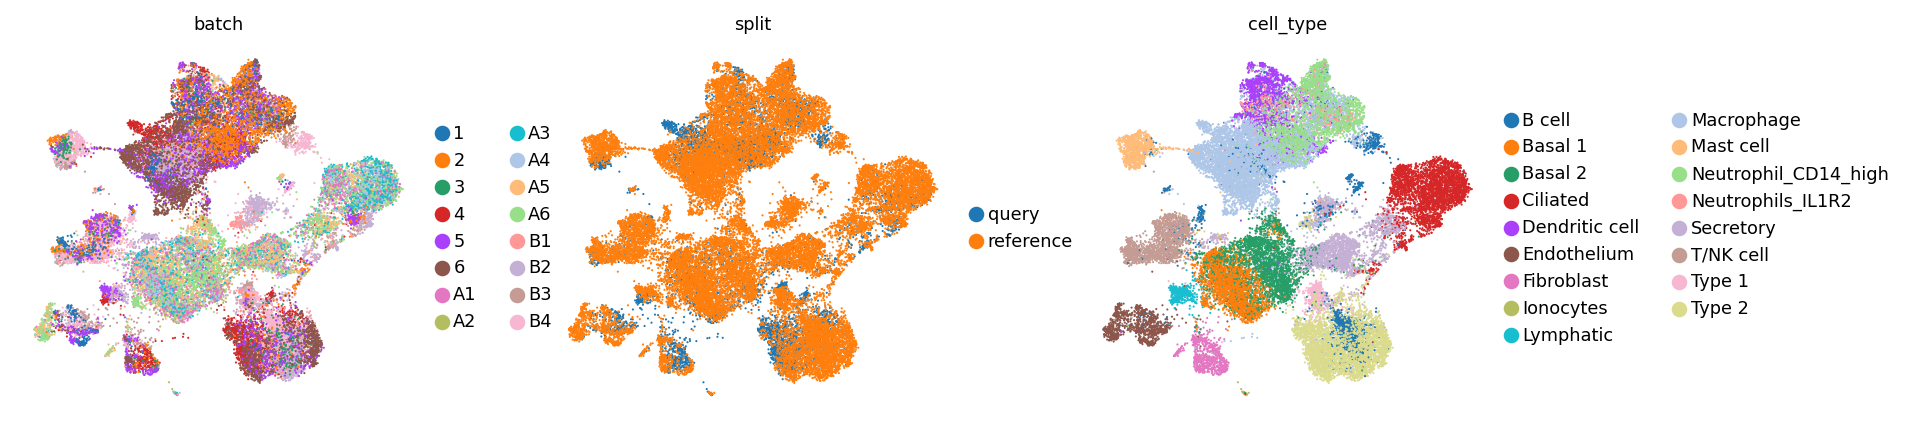

In [52]:
with plt.rc_context({"figure.figsize": (3.3, 3), "legend.fontsize": 8, "axes.titlesize": 8}):
    sc.pl.embedding(ad_combined, basis=SCVI_UMAP_KEY, color=["batch", "split", "cell_type"], wspace=0.2)

Copy this joint umap back into the individual AnnData objects. 

In [25]:
ad_query.obsm[SCVI_UMAP_KEY] = ad_combined[ad_combined.obs["split"] == "query"].obsm[SCVI_UMAP_KEY].copy()
ad_reference.obsm[SCVI_UMAP_KEY] = ad_combined[ad_combined.obs["split"] == "reference"].obsm[SCVI_UMAP_KEY].copy()

## Work with CellMaper

### Transfer celltype labels

We'll use a non-default mapping method below (`hnoca`). You can experiment a bit with this - CellMapper implements many different ways of turning k-NN graphs into mapping matrices. `hnoca` is a certain normalization of Jaccard similarities, following the original implementation in [HNOCA-tools](https://devsystemslab.github.io/HNOCA-tools/). 

In [43]:
cmap = cellmapper.CellMapper(ad_query, ad_reference).map(
    obs_keys=["cell_type"], use_rep=SCVI_LATENT_KEY, mapping_method="hnoca"
)
cmap

INFO     Initialized CellMapper with 7128 query cells and 25344 reference cells.                                   
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using method 'hnoca'.                                                            
INFO     Mapping categorical data for key 'cell_type' using direct multiplication.                                 
INFO     Categorical data mapped and stored in query.obs['cell_type_pred'].                                        


CellMapper(query=AnnData(n_obs=7,128, n_vars=2,000), reference=AnnData(n_obs=25,344, n_vars=2,000)

Let's compare the predicted labels with ground truth

In [44]:
cmap.evaluate_label_transfer("cell_type")

INFO     Accuracy: 0.7755, Precision: 0.9280, Recall: 0.7755, Weighted F1-Score: 0.8203, Macro F1-Score: 0.7266,   
         Excluded Fraction: 0.0000                                                                                 


A weighted F1 score of 0.82 is quite good here. Let's take a look at the confusion matrix to learn more. 

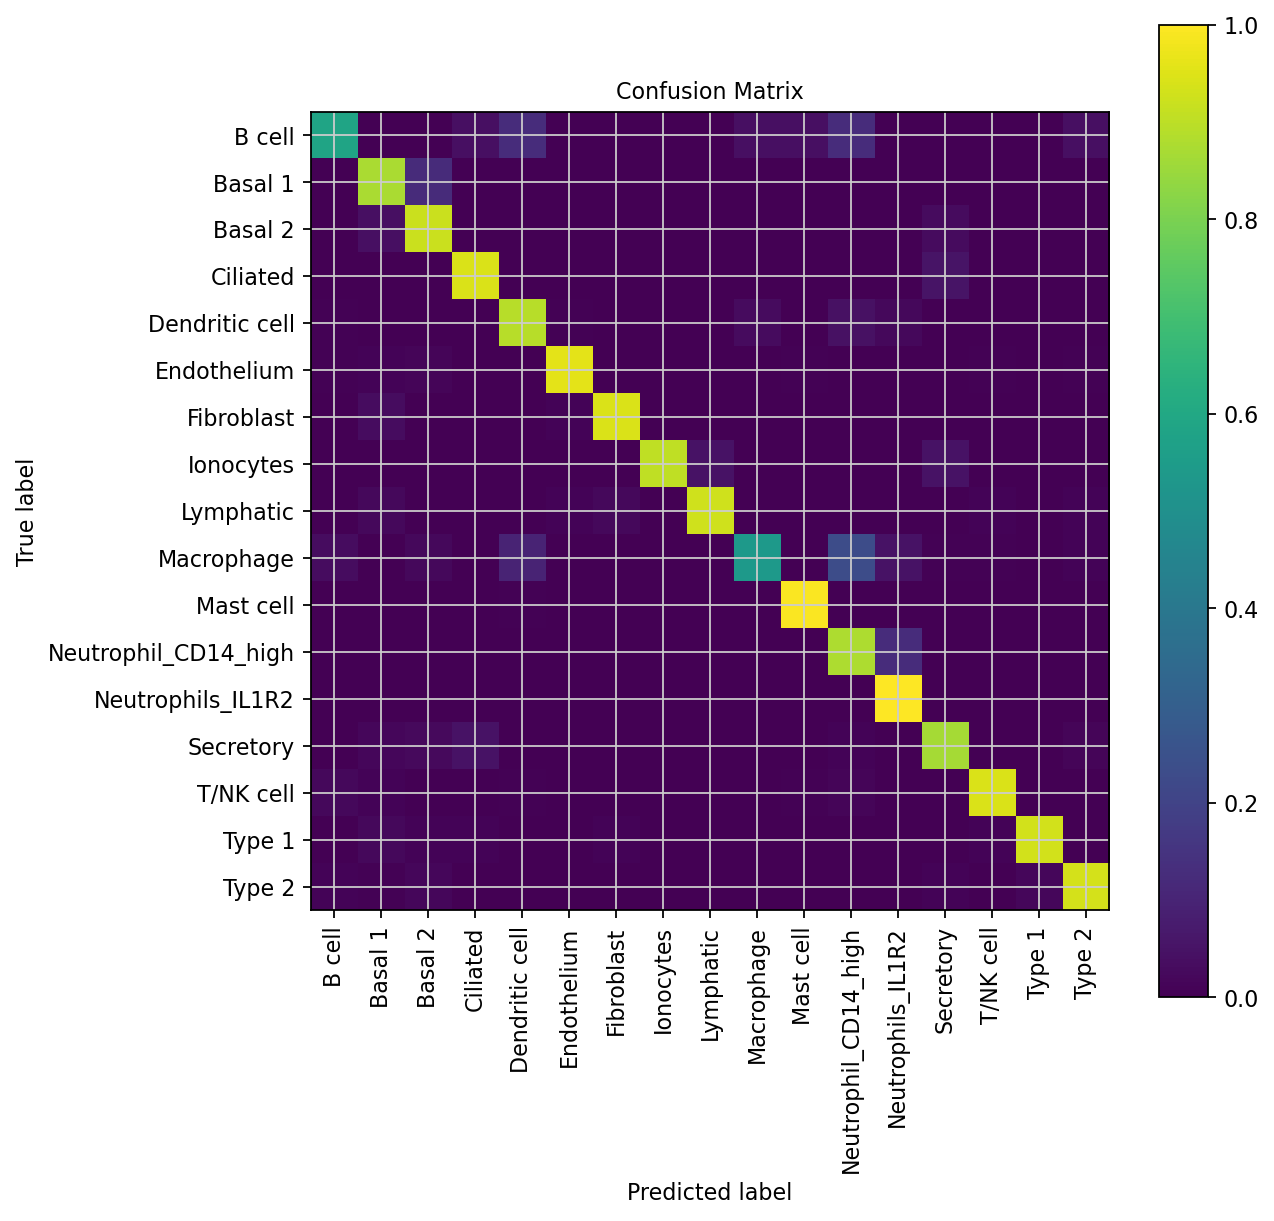

In [45]:
cmap.plot_confusion_matrix("cell_type", normalize="true", include_values=False, figsize=(8, 8))

For most cell types, we're doing quite well. Let's also compare ground-truth with predicted labels in the umap. 

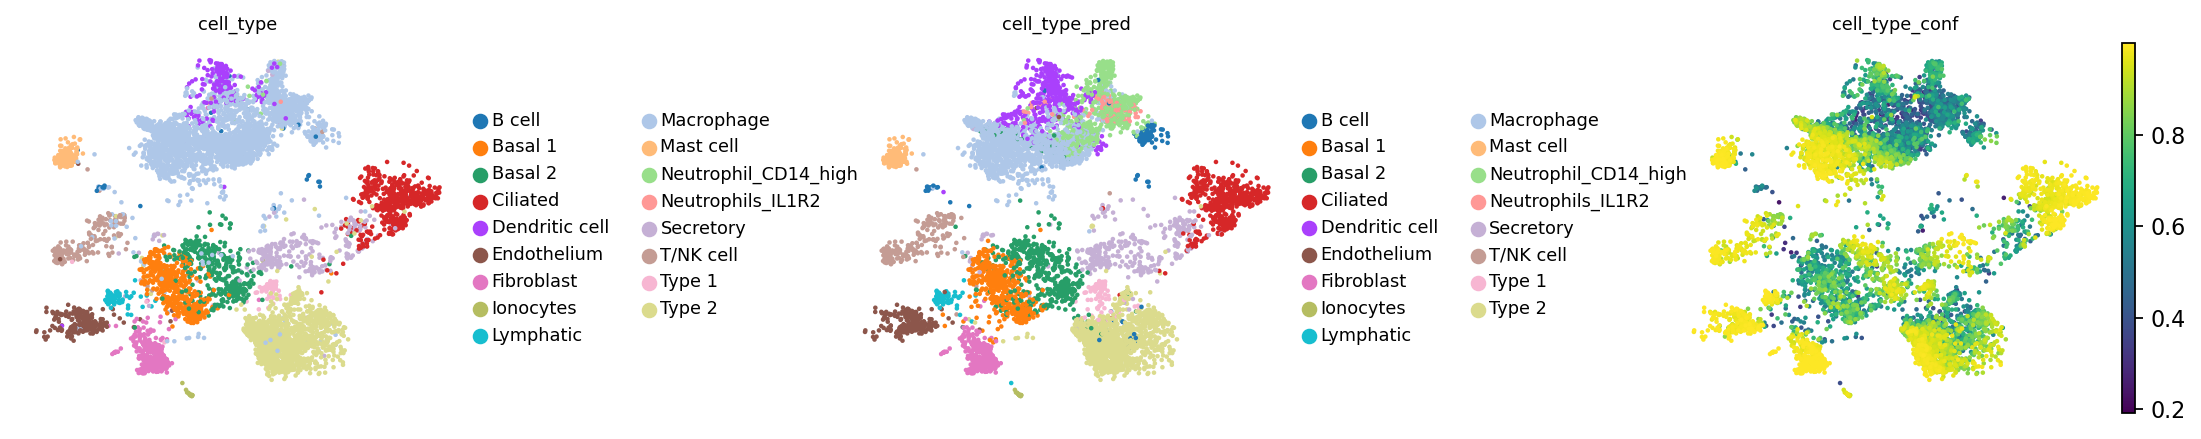

In [53]:
with plt.rc_context({"figure.figsize": (3.3, 3), "legend.fontsize": 8, "axes.titlesize": 8}):
    sc.pl.embedding(ad_query, basis=SCVI_UMAP_KEY, color=["cell_type", "cell_type_pred", "cell_type_conf"], wspace=0.7)

For cells where the prediction does not match the ground truth label, it looks like the confidence score is usually lower. 

### Compute presence scores

Next, we would like to figure out how well represented each query cell is in the reference atlas. Such an analysis is particularly useful in disease studies, where particular cell types might be depleted or enriched, compared to a healthy reference atlas. 

In [32]:
cmap.compute_presence_score(groupby="batch")

INFO     Presence score across all query cells computed and stored in `reference.obs['presence_score']`            
INFO     Presence scores per group defined in `query.obs['batch']` computed and stored in                          
         `reference.obsm['presence_score']`                                                                        


Following the corresponding implementation in HNOCA-tools {cite:p}`he2024integrated`, we smooth out the presence scores a bit. 

In [33]:
smap = cellmapper.CellMapper(ad_reference).map(obs_keys="presence_score", t=5, use_rep=SCVI_LATENT_KEY)

INFO     Initialized CellMapper for self-mapping with 25344 cells.                                                 
INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using method 'gauss'.                                                            
INFO     Mapping numerical data for key 'presence_score' with t=5 steps using iterative method.                    
INFO     Numerical data mapped and stored in query.obs['presence_score_pred'].                                     


Visualize these scores on the joint umap. 

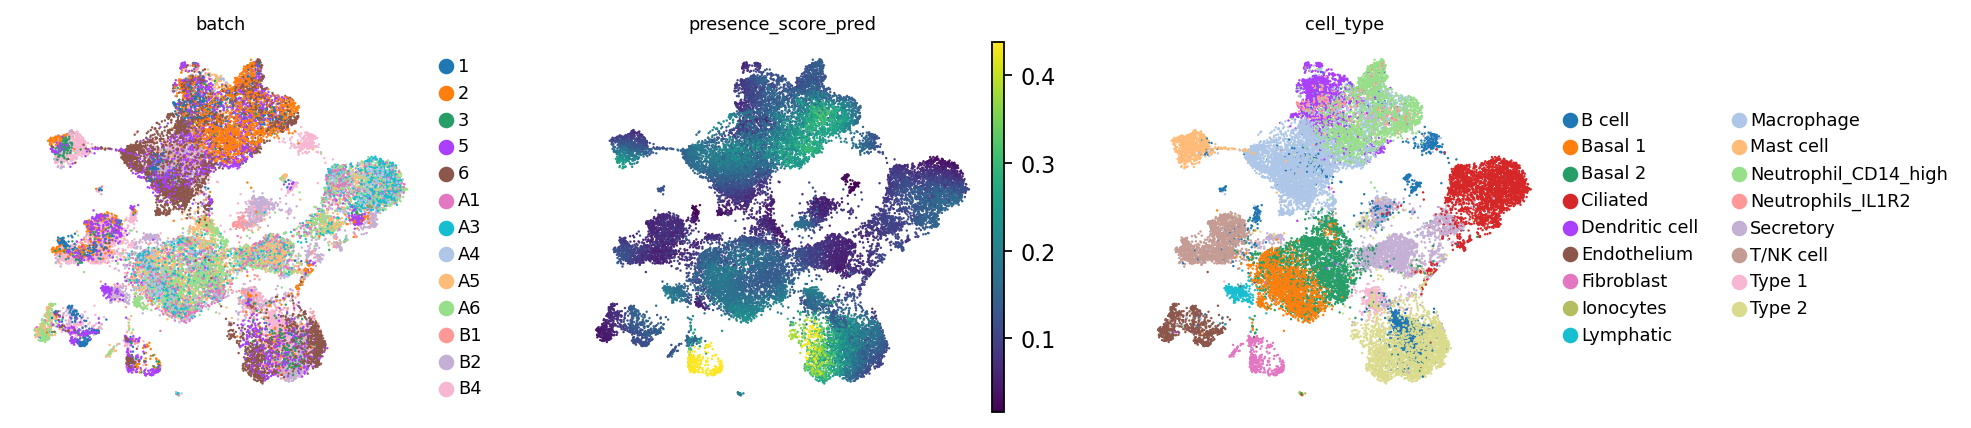

In [54]:
with plt.rc_context({"figure.figsize": (3.3, 3), "legend.fontsize": 8, "axes.titlesize": 8}):
    sc.pl.embedding(ad_reference, basis=SCVI_UMAP_KEY, color=["batch", "presence_score_pred", "cell_type"], vmax="p99")

We can now stratify this by cell type in the reference. 

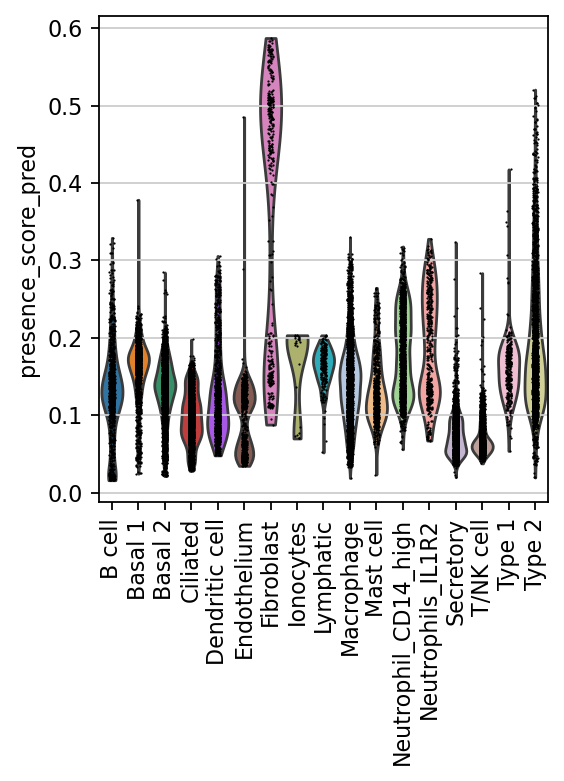

In [35]:
sc.pl.violin(ad_reference, keys="presence_score_pred", groupby="cell_type", rotation=90)

It looks like our query dataset is enriched for Fibroblasts, relative to the reference. However, the query itself consitst of three batches - let's check whether this batches are equally represented in the reference, or whether there are differences. For this, CellMapper wrote a DataFrame to `.obsm` - we also apply some smoothing to that here. 

In [36]:
smap = cellmapper.CellMapper(ad_reference).map(obsm_keys="presence_score", t=5, use_rep=SCVI_LATENT_KEY)

INFO     Initialized CellMapper for self-mapping with 25344 cells.                                                 
INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using method 'gauss'.                                                            
INFO     Mapping embeddings for key 'presence_score' with t=5 steps using iterative method                         
INFO     Embeddings mapped and stored in query.obsm['presence_score_pred']                                         


Let's copy the final presence scores per batch into `.obs` and visualize. 

In [37]:
obsm_key = "presence_score_pred"
obs_score_names = [f"{obsm_key}_{key}" for key in query_batches]

for obsm_name, obs_name in zip(query_batches, obs_score_names, strict=False):
    ad_reference.obs[obs_name] = ad_reference.obsm[obsm_key][obsm_name]

Visualize in the UMAP

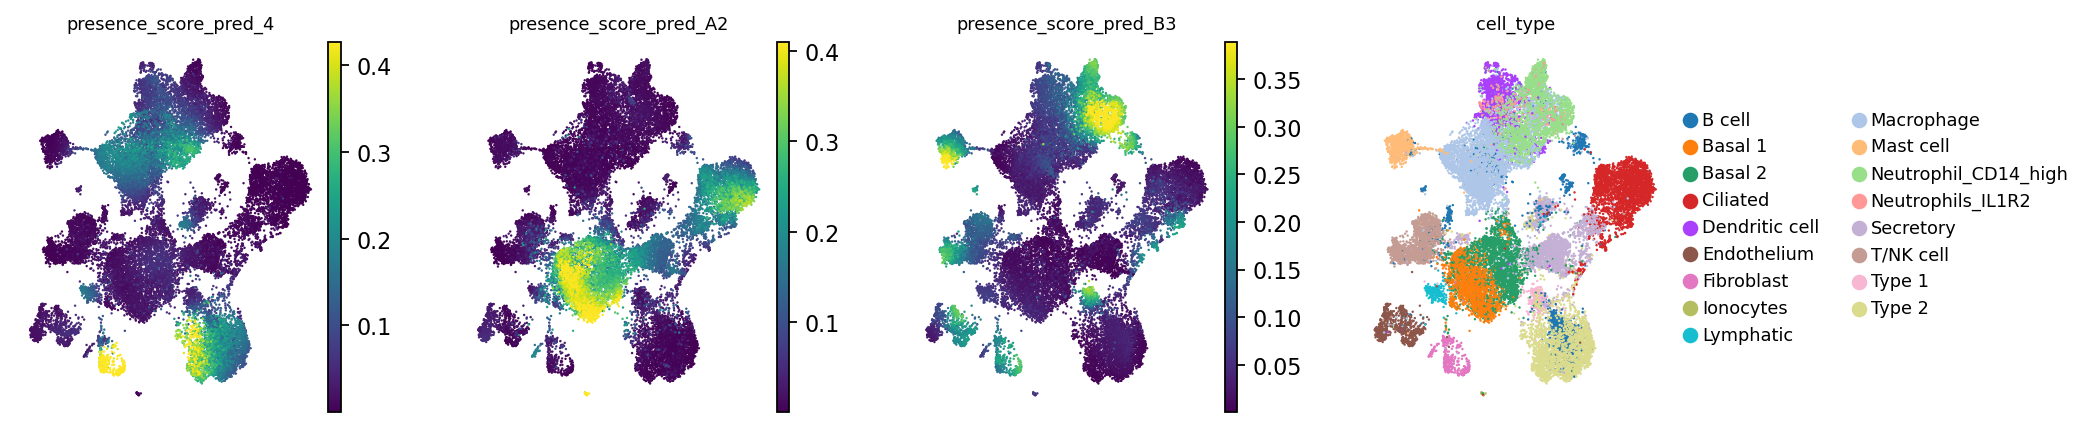

In [55]:
with plt.rc_context({"figure.figsize": (2.5, 3), "legend.fontsize": 8, "axes.titlesize": 8}):
    sc.pl.embedding(ad_reference, basis="umap_scVI", color=obs_score_names + ["cell_type"], vmax="p99")

It looks like the different query batches cover different parts of the phenotypic manifold described by the reference dataset. We can summarize this result in a dotplot. 

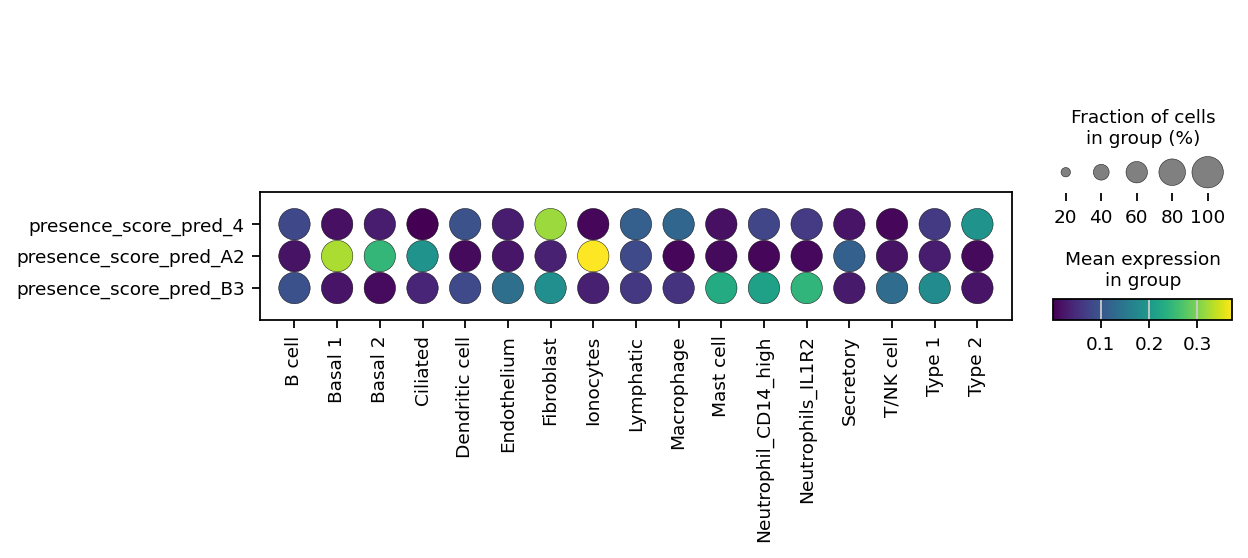

In [39]:
# Set up dummy AnnData object
X = ad_reference.obs[obs_score_names].values
dummy_adata = ad.AnnData(
    X=X,
    obs=ad_reference.obs[["cell_type"]].copy(),
    var=pd.DataFrame(index=obs_score_names),  # features as .var_names
)

sc.pl.dotplot(dummy_adata, var_names=obs_score_names, groupby="cell_type", color_map="viridis", swap_axes=True)

We now see that the enrichment for fibroblasts stems only from a single batch - the other query batches cover different parts of the reference landscape.  